## <font color="royalblue">**Pre_Procesamiento de datos**</font> 
### <font color="royalblue">**Depuración de datos**</font> 
Revision de los dataframe para identificar datos faltantes y duplicados   
El resultado sera una version _clean que sera el input al procesamiento del lenguaje natural (NLP)

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


In [ ]:
df_Adzuna=pd.read_csv('df_Adzuna_preproc.csv')                
df_Indeed=pd.read_csv('df_Indeed_preproc.csv')
df_LinkedIn=pd.read_csv('df_LinkedIn_preproc.csv')

In [117]:
# Calcular cantidad de registros por portal
num_registros_Adzuna = len(df_Adzuna)
num_registros_Indeed = len(df_Indeed)
num_registros_LinkedIn = len(df_LinkedIn)
print(f"Adzuna: {num_registros_Adzuna} registros\nIndeed: {num_registros_Indeed} registros\nLinkedIn: {num_registros_LinkedIn} registros")

Adzuna: 76 registros
Indeed: 139 registros
LinkedIn: 100 registros


### <font color="royalblue">Situación de los datos</font>
Es importante identificar la condición de los datos previo a realizar el analisis de las descripciones de las ofertas.
Particularmente si hay presencia de duplicados y faltantes. Por tal motivo se definen funciones que permitan encontrar estas inconsistencias en los dataframe de los portales. Las url que permitieron la extracccion de las descripciones, id que identifican a cada oferta y los mas importante las descripciones que suministraran las solicitudes de cada oferta de empleo.

In [118]:
def urls_problema(df, nombre):
    vacias = df[df["url"].isna()]
    duplicadas = df[df.duplicated(subset=["url"], keep=False)]
    print(f" URLs vacías: {len(vacias)}")
    print(f" URLs duplicadas: {len(duplicadas)}")

# Detectar duplicados por portal
def ids_duplicados(df, nombre):
    dups = df[df.duplicated(subset=["id"], keep=False)]
    print(f" IDs duplicados: {len(dups)}")
    return dups

def descripciones_duplicadas(df, nombre):
    duplicadas = df[df.duplicated(subset=["descripcion"], keep=False)]
    print(f" Descripciones duplicadas: {len(duplicadas)}")
    return duplicadas

# Detectar ofertas sin descripción
def sin_descripcion(df, nombre):
    vacias = df[df["descripcion"].isna()]
    print(f" Ofertas sin descripción: {len(vacias)}")
    return vacias

# Detectar ofertas “vacías” (solo ID + URL)
def ofertas_incompletas(df, nombre):
    columnas_clave = ["titulo", "empresa", "descripcion"]
    incompletas = df[df[columnas_clave].isna().all(axis=1)]
    print(f" Ofertas incompletas: {len(incompletas)}")
    return incompletas


In [119]:
# Resumen de calidad total por portal
def calidad_portal(df, nombre):
    print(f"\n===== 📌 Calidad del portal: {nombre} =====")
    urls_problema(df, nombre)
    ids_duplicados(df, nombre)
    descripciones_duplicadas(df, nombre)
    sin_descripcion(df, nombre)
    ofertas_incompletas(df, nombre)
    

In [120]:
calidad_portal(df_LinkedIn, "LinkedIn")
calidad_portal(df_Indeed, "Indeed")
calidad_portal(df_Adzuna, "Adzuna")


===== 📌 Calidad del portal: LinkedIn =====
 URLs vacías: 0
 URLs duplicadas: 0
 IDs duplicados: 0
 Descripciones duplicadas: 5
 Ofertas sin descripción: 0
 Ofertas incompletas: 0

===== 📌 Calidad del portal: Indeed =====
 URLs vacías: 0
 URLs duplicadas: 0
 IDs duplicados: 0
 Descripciones duplicadas: 28
 Ofertas sin descripción: 24
 Ofertas incompletas: 7

===== 📌 Calidad del portal: Adzuna =====
 URLs vacías: 0
 URLs duplicadas: 0
 IDs duplicados: 0
 Descripciones duplicadas: 5
 Ofertas sin descripción: 0
 Ofertas incompletas: 0


- Es importante resaltar que no se identifican url e id repetidos o sin información.  
- Pero si se tiene descripciones duplicadas, sin informacion o imcompletas, las cuales a continuacion se tratarán.

#### <font color="royalblue">**Descripciones Duplicadas**</font>

In [121]:
def duplicadas(df, columna, portal):
    duplicadas = df[df.duplicated(subset=[columna], keep=False)]
    print(f"\n🔁 {columna.capitalize()}: {len(duplicadas)} registros duplicados de {portal}")
    return duplicadas



🔁 Descripcion: 5 registros duplicados de LinkedIn

🔁 Descripcion: 28 registros duplicados de Indeed

🔁 Descripcion: 5 registros duplicados de Adzuna


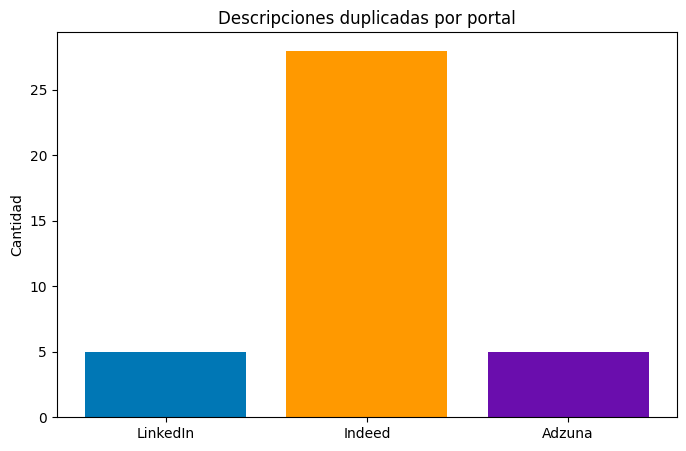

In [122]:
duplicados_descripciones = {
    "LinkedIn": duplicadas(df_LinkedIn, "descripcion", "LinkedIn").shape[0],
    "Indeed": duplicadas(df_Indeed, "descripcion", "Indeed").shape[0],
    "Adzuna": duplicadas(df_Adzuna, "descripcion", "Adzuna").shape[0]
}

plt.figure(figsize=(8,5))
plt.bar(duplicados_descripciones.keys(), duplicados_descripciones.values(), color=["#0077b5", "#ff9900", "#6a0dad"])
plt.title("Descripciones duplicadas por portal")
plt.ylabel("Cantidad")
plt.show()


In [123]:
duplicadas(df_Adzuna, "descripcion", "Adzuna")


🔁 Descripcion: 5 registros duplicados de Adzuna


,titulo,empresa,ubicacion,modalidad,tipo_contrato,contract_type,experiencia_años,experiencia_nivel,nivel_educativo,hard_skills,soft_skills,idiomas,fecha,contrac_time,category,descripcion,portal_web,id,url,es_truncada
11,Marketing Data Analyst,Proton,Barcelona,NaN,NaN,NaN,NaN,becario,NaN,NaN,NaN,NaN,2026-03-05T20:55:01Z,NaN,NaN,Join Proton and build a better internet where ...,Adzuna,5655180976,https://www.adzuna.es/details/5655180976?utm_m...,True
12,Marketing Data Analyst,Proton Ag,Barcelona,NaN,NaN,NaN,NaN,becario,NaN,NaN,NaN,NaN,2026-03-05T20:55:17Z,NaN,NaN,Join Proton and build a better internet where ...,Adzuna,5655182688,https://www.adzuna.es/details/5655182688?utm_m...,True
13,Marketing Data Analyst,Proton Ag,Barcelona,NaN,NaN,NaN,NaN,becario,NaN,NaN,NaN,NaN,2026-03-05T20:54:54Z,NaN,NaN,Join Proton and build a better internet where ...,Adzuna,5655180333,https://www.adzuna.es/details/5655180333?utm_m...,True
21,"Principal Data Analyst Barcelona, Spain",Zynga,Barcelona,NaN,NaN,NaN,NaN,senior,NaN,NaN,NaN,NaN,2026-03-06T20:55:51Z,NaN,NaN,"At Zynga, we bring people together through the...",Adzuna,5656543416,https://www.adzuna.es/details/5656543416?utm_m...,True
22,"Principal Data Analyst Barcelona, Spain",Zynga,Barcelona,NaN,NaN,NaN,NaN,senior,NaN,NaN,NaN,NaN,2026-03-07T20:56:24Z,NaN,NaN,"At Zynga, we bring people together through the...",Adzuna,5657839002,https://www.adzuna.es/details/5657839002?utm_m...,True


In [124]:
duplicadas(df_Indeed, "descripcion", "Indeed")


🔁 Descripcion: 28 registros duplicados de Indeed


,titulo,empresa,ubicacion,modalidad,tipo_contrato,experiencia_años,experiencia_nivel,nivel_educativo,hard_skills,soft_skills,idiomas,salario,descripcion,portal_web,id,url
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indeed,cdef0123456789ab,https://es.indeed.com/viewjob?jk=cdef0123456789ab
11,Data Governance Expert for Data Analytics Tools,Fusion Consulting,"Barcelona, Barcelona provincia",NaN,Jornada completa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indeed,89ef7e9d17dc9cc3,https://es.indeed.com/viewjob?jk=89ef7e9d17dc9cc3
12,"Business Analyst Intern, Barcelona",Mirakl,"Barcelona, Barcelona provincia",NaN,Contrato en prácticas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indeed,a90082a231e49905,https://es.indeed.com/viewjob?jk=a90082a231e49905
22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indeed,789abcdef0123456,https://es.indeed.com/viewjob?jk=789abcdef0123456
26,Senior Data Analyst,Smadex SLU,"08009 Barcelona, Barcelona provincia",NaN,Jornada completa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indeed,b6f1626b2c6e7a3e,https://es.indeed.com/viewjob?jk=b6f1626b2c6e7a3e
27,Data Analyst,Vestacy,"08403 Granollers, Barcelona provincia",NaN,Jornada completa +1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indeed,5de868a449bf6bb6,https://es.indeed.com/viewjob?jk=5de868a449bf6bb6
33,Junior Supply Chain Data analyst,Bluecrux,"08019 Barcelona, Barcelona provincia",híbrido,Jornada completa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indeed,caf2c57f65ba0e10,https://es.indeed.com/viewjob?jk=caf2c57f65ba0e10
36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indeed,f1e2d3c4b5a67890,https://es.indeed.com/viewjob?jk=f1e2d3c4b5a67890
38,Jr sales analyst,Claire Joster,"Esplugues de Llobregat, Barcelona provincia",NaN,Jornada intensiva en verano,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indeed,859ff93cf658fc6d,https://es.indeed.com/viewjob?jk=859ff93cf658fc6d
42,Data Engineering Lead,SeQura,"08010 Barcelona, Barcelona provincia",remoto,Jornada completa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Indeed,e0d21206dd875602,https://es.indeed.com/viewjob?jk=e0d21206dd875602


In [125]:
duplicadas(df_LinkedIn, "descripcion", "Linkedin")


🔁 Descripcion: 5 registros duplicados de Linkedin


,titulo,empresa,ubicacion,modalidad,tipo_contrato,experiencia_años,experiencia_nivel,nivel_educativo,hard_skills,soft_skills,idiomas,fecha,descripcion,portal_web,id,url
1,Data Analyst Junior\nData Analyst Junior,Evolve,España,En remoto,prácticas,NaN,becario,grado,"python, sql, power bi, pandas, scikit-learn",NaN,NaN,NaN,\nDescripción de la oferta\nEn nuestro Program...,LinkedIn,4381466326,https://www.linkedin.com/jobs/view/4381466326/
15,Data analyst\nData analyst with verification,Bending Spoons,"Barcelona, Cataluña, España",Híbrido,indefinido,NaN,senior,NaN,"excel, git",NaN,inglés,NaN,"\nAt Bending Spoons, we’re striving to build o...",LinkedIn,4381003567,https://www.linkedin.com/jobs/view/4381003567/
26,Junior Data Analyst\nJunior Data Analyst,Evolve,España,En remoto,prácticas,NaN,becario,grado,"python, sql, power bi, pandas, scikit-learn",NaN,NaN,NaN,\nDescripción de la oferta\nEn nuestro Program...,LinkedIn,4381451949,https://www.linkedin.com/jobs/view/4381451949/
38,Graduate data analyst\nGraduate data analyst w...,Bending Spoons,"Barcelona, Cataluña, España",Híbrido,indefinido,NaN,senior,NaN,"excel, git",NaN,inglés,NaN,"\nAt Bending Spoons, we’re striving to build o...",LinkedIn,4380698758,https://www.linkedin.com/jobs/view/4380698758/
90,Data scientist\nData scientist with verification,Bending Spoons,"Barcelona, Cataluña, España",Híbrido,indefinido,NaN,senior,NaN,"excel, git",NaN,inglés,NaN,"\nAt Bending Spoons, we’re striving to build o...",LinkedIn,4379699205,https://www.linkedin.com/jobs/view/4379699205/


In [126]:
def eliminar_duplicados(df, columna="descripcion"):
    df = df.copy()
    df["duplicada"] = df.duplicated(subset=[columna], keep="first")
    # Separar nulos y no nulos
    df_null = df[df[columna].isnull()].copy()
    df_notnull = df[df[columna].notnull()].copy()

    # Eliminar duplicados solo en los no nulos
    df_notnull_unicos = df_notnull.drop_duplicates(subset=[columna], keep="first")

    # Unir de nuevo
    df_unicos = pd.concat([df_notnull_unicos, df_null], ignore_index=True)
    
    return df_unicos


In [127]:
df_Adzuna = eliminar_duplicados(df_Adzuna)
df_Indeed = eliminar_duplicados(df_Indeed)
df_LinkedIn = eliminar_duplicados(df_LinkedIn)


Comprobación de resultados de descripciones duplicadas: 
Las descripciones en el portal Indeed corresponden a descripciones vacias.


In [128]:
duplicadas(df_LinkedIn, "descripcion", "LinkedIn")
duplicadas(df_Indeed, "descripcion", "Indeed")
duplicadas(df_Adzuna, "descripcion", "Adzuna")


🔁 Descripcion: 0 registros duplicados de LinkedIn

🔁 Descripcion: 24 registros duplicados de Indeed

🔁 Descripcion: 0 registros duplicados de Adzuna


,titulo,empresa,ubicacion,modalidad,tipo_contrato,contract_type,experiencia_años,experiencia_nivel,nivel_educativo,hard_skills,...,idiomas,fecha,contrac_time,category,descripcion,portal_web,id,url,es_truncada,duplicada


#### <font color="royalblue">**Datos faltantes**</font>

In [129]:
calidad_portal(df_LinkedIn, "LinkedIn")
calidad_portal(df_Indeed, "Indeed")
calidad_portal(df_Adzuna, "Adzuna")


===== 📌 Calidad del portal: LinkedIn =====
 URLs vacías: 0
 URLs duplicadas: 0
 IDs duplicados: 0
 Descripciones duplicadas: 0
 Ofertas sin descripción: 0
 Ofertas incompletas: 0

===== 📌 Calidad del portal: Indeed =====
 URLs vacías: 0
 URLs duplicadas: 0
 IDs duplicados: 0
 Descripciones duplicadas: 24
 Ofertas sin descripción: 24
 Ofertas incompletas: 7

===== 📌 Calidad del portal: Adzuna =====
 URLs vacías: 0
 URLs duplicadas: 0
 IDs duplicados: 0
 Descripciones duplicadas: 0
 Ofertas sin descripción: 0
 Ofertas incompletas: 0


Analisis del estado de las ofertas con descripciones incompletas y vacias de Indeed
Como se aprecia en calidad del portal, se revisaran las 24 ofertas sin decripcion y las 7 ofertas incompletas. Para esto se ejecuta una funcion que analiza el subconjunto de ambos grupos de ofertas (df_incompletas y df_sin_descripcion) y las columnas con y sin informacion de cada grupo. 

In [130]:
# Identificar columnas con faltantes
def columnas_vacias(df):
    return df.columns[df.isna().all()].tolist()

def columnas_llenas(df):
    return df.columns[df.notna().all()].tolist()

def columnas_parciales(df):
    return df.columns[df.notna().any() & df.isna().any()].tolist()

def analisis_columnas(df, portal):
    vacias = columnas_vacias(df)
    parciales = columnas_parciales(df)
    llenas = columnas_llenas(df)
    
    print(f"\nAnálisis de columnas para {portal}:")
    print("Columnas vacías:", vacias)
    print("Columnas parciales:", parciales)
    print("Columnas llenas:", llenas)



Las 7 ofertas imcompletas carecen de todas las variables requeridas para generar
cualquier tipo de analisis, por tal motivo pueden ser eliminados del dataframe

In [131]:
df_incompletas = ofertas_incompletas(df_Indeed, "Indeed")
analisis_columnas(df_incompletas, "Indeed")


 Ofertas incompletas: 7

Análisis de columnas para Indeed:
Columnas vacías: ['titulo', 'empresa', 'ubicacion', 'modalidad', 'tipo_contrato', 'experiencia_años', 'experiencia_nivel', 'nivel_educativo', 'hard_skills', 'soft_skills', 'idiomas', 'salario', 'descripcion']
Columnas parciales: []
Columnas llenas: ['portal_web', 'id', 'url', 'duplicada']


In [132]:
def eliminar_ofertas_incompletas(df):
    df = df.copy()
    print("Eliminadas de portal:", "Indeed")
    df_incompletas = ofertas_incompletas(df, "Indeed")
    df = df.drop(df_incompletas.index)
    return df    

In [133]:
df_Indeed = eliminar_ofertas_incompletas(df_Indeed)

Eliminadas de portal: Indeed
 Ofertas incompletas: 7


In [134]:
ofertas_incompletas(df_Indeed, "Indeed")

 Ofertas incompletas: 0


,titulo,empresa,ubicacion,modalidad,tipo_contrato,experiencia_años,experiencia_nivel,nivel_educativo,hard_skills,soft_skills,idiomas,salario,descripcion,portal_web,id,url,duplicada


Las 24 ofertas sin descripcion se reducen a 17, despues de eliminar las ofertas incompletas. Cuentan con campos como titulo, empresa, ubicacion y parcialmente modalidad como lo muestra el analisis de columnas y el grafico de faltantes por columnas.
Por tal motivo de momento se mantiene en el dataframe.

In [135]:
df_sin_descripcion = sin_descripcion(df_Indeed, "Indeed")
analisis_columnas(df_sin_descripcion, "Indeed")


 Ofertas sin descripción: 17

Análisis de columnas para Indeed:
Columnas vacías: ['experiencia_años', 'experiencia_nivel', 'nivel_educativo', 'hard_skills', 'soft_skills', 'idiomas', 'salario', 'descripcion']
Columnas parciales: ['modalidad', 'tipo_contrato']
Columnas llenas: ['titulo', 'empresa', 'ubicacion', 'portal_web', 'id', 'url', 'duplicada']


<Axes: >

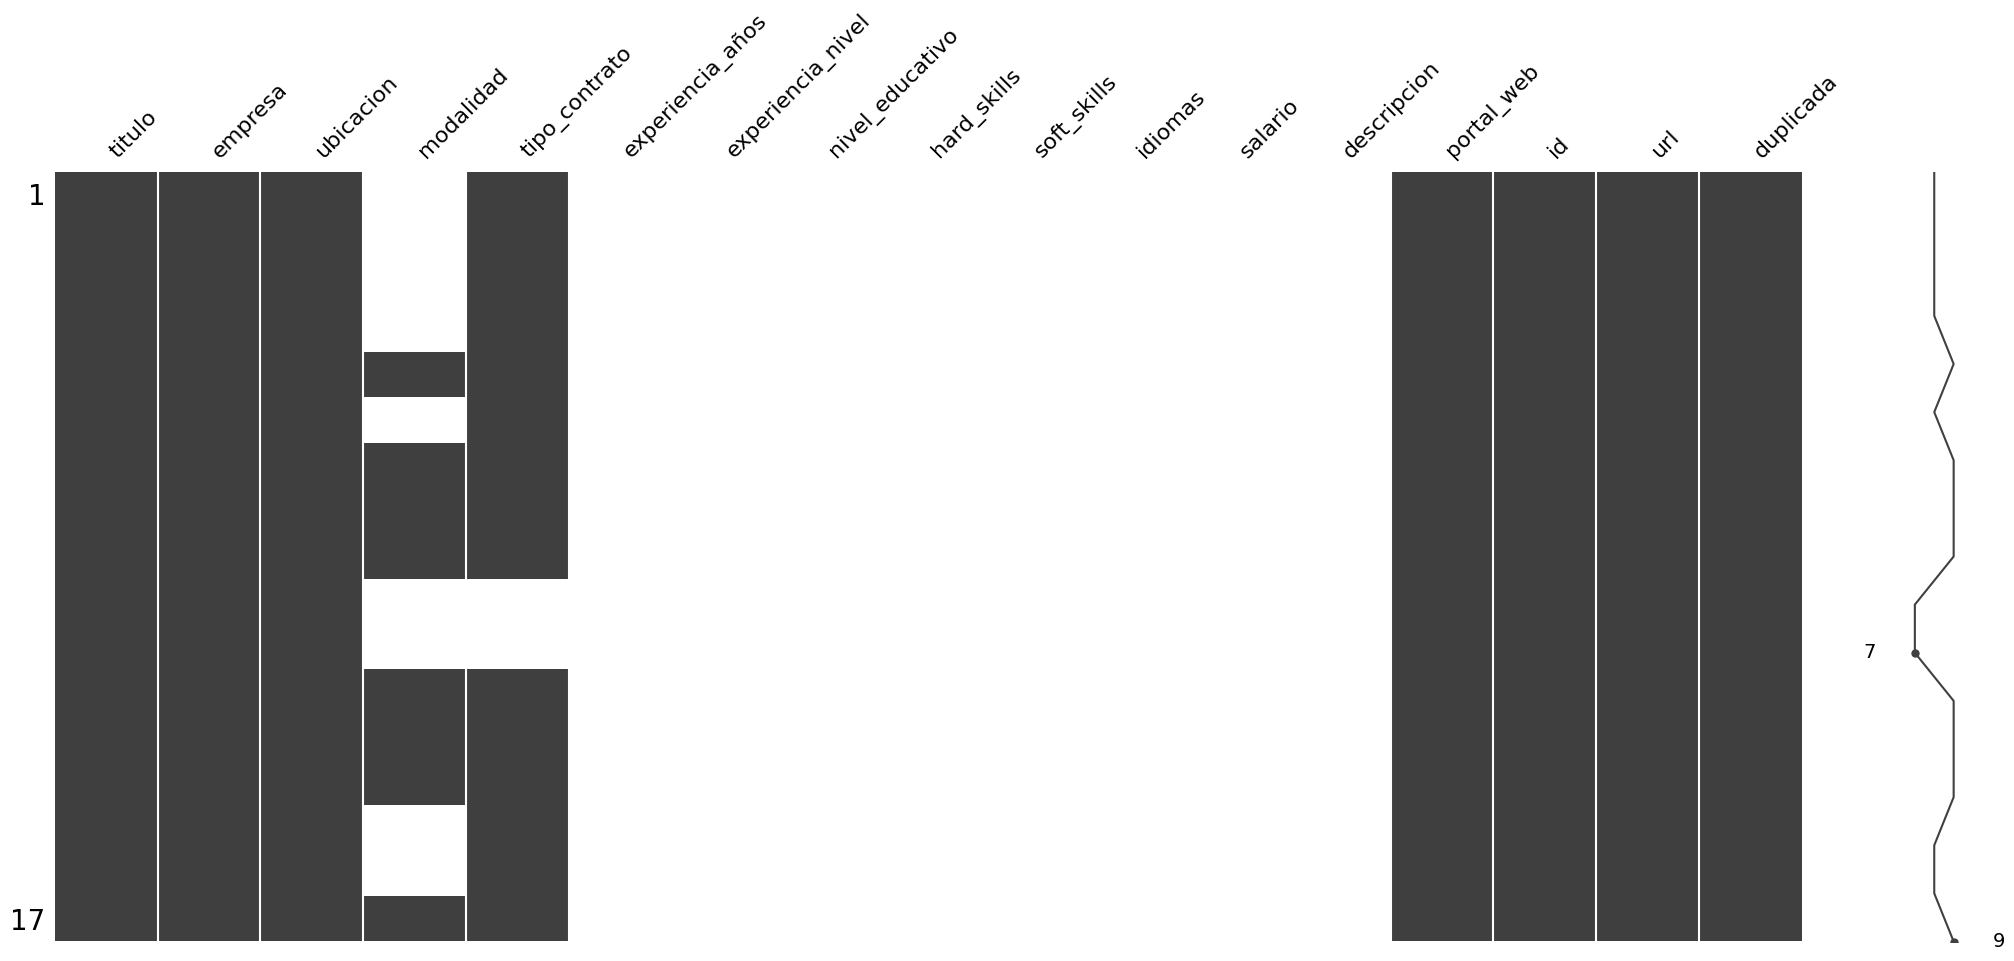

In [136]:
msno.matrix(df_sin_descripcion)

<Axes: >

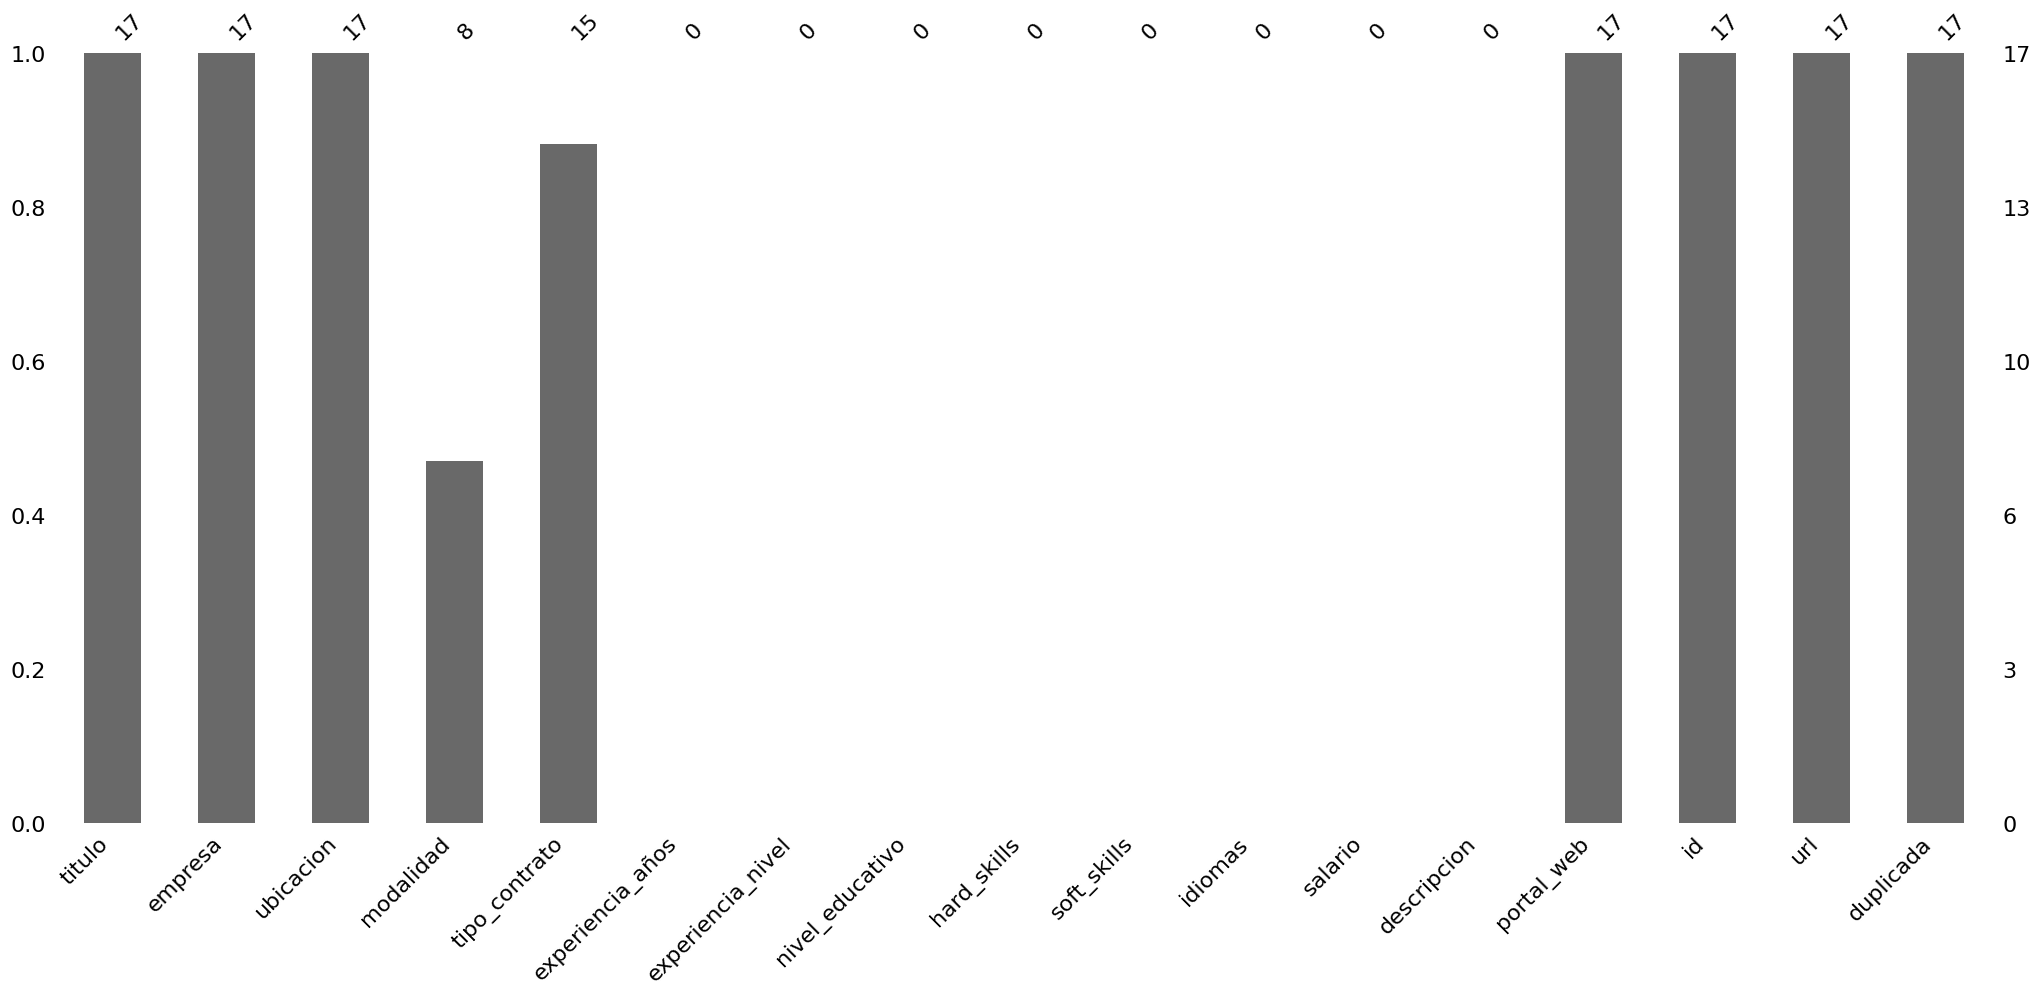

In [137]:
msno.bar(df_sin_descripcion)

Ahora se revisaran el resto de campos para observa el nivel de completitud y faltantes para cada portal  
Se creara df de datos faltantes por portal y global 

In [138]:
df_col_faltantes = pd.concat([(df_LinkedIn.isna().sum().rename("LinkedIn")), (df_Indeed.isna().sum().rename("Indeed")), (df_Adzuna.isna().sum().rename("Adzuna"))], axis=1)
df_col_faltantes

,LinkedIn,Indeed,Adzuna
titulo,0.0,0.0,0.0
empresa,0.0,0.0,3.0
ubicacion,0.0,0.0,0.0
modalidad,11.0,52.0,45.0
tipo_contrato,22.0,30.0,49.0
experiencia_años,53.0,44.0,51.0
experiencia_nivel,19.0,32.0,18.0
nivel_educativo,45.0,67.0,53.0
hard_skills,11.0,23.0,30.0
soft_skills,28.0,33.0,30.0


In [139]:
num_ofertas_adzuna = len(df_Adzuna) # df_Adzuna
num_ofertas_indeed = len(df_Indeed) # df_Indeed
num_ofertas_linkedin = len(df_LinkedIn) # df_LinkedIn

df_col_faltantes_pct = df_col_faltantes.copy()
df_col_faltantes_pct["LinkedIn"] = round(df_col_faltantes["LinkedIn"] / num_ofertas_linkedin * 100, 2)
df_col_faltantes_pct["Indeed"]   = round(df_col_faltantes["Indeed"]   / num_ofertas_indeed   * 100, 2)
df_col_faltantes_pct["Adzuna"]   = round(df_col_faltantes["Adzuna"]   / num_ofertas_adzuna   * 100, 2)
df_col_faltantes_pct


,LinkedIn,Indeed,Adzuna
titulo,0.00,0.00,0.00
empresa,0.00,0.00,4.11
ubicacion,0.00,0.00,0.00
modalidad,11.34,40.00,61.64
tipo_contrato,22.68,23.08,67.12
experiencia_años,54.64,33.85,69.86
experiencia_nivel,19.59,24.62,24.66
nivel_educativo,46.39,51.54,72.60
hard_skills,11.34,17.69,41.10
soft_skills,28.87,25.38,41.10


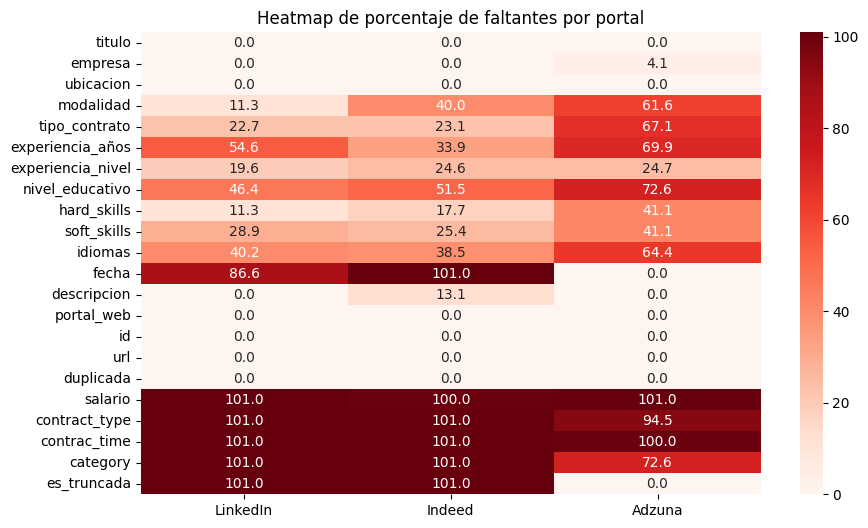

In [ ]:
df_comp_faltantes = df_col_faltantes_pct.fillna(101)

plt.figure(figsize=(10,6))
sns.heatmap(
    df_comp_faltantes,
    annot=True,
    cmap="Reds",
    fmt=".1f"
)
plt.title("Heatmap de porcentaje de faltantes por portal")
plt.show()


Analizando los porcentajes altos de datos faltantes, se puede observar que datos no se pueden descartar de los dataframe de los portales, por no se lo suficientemente representatativo como para aplicar algun tipo de analisis a posterior.  
Para Indeed y Linkedin las columnas como **fecha, salario, contract_type, contrac_time y category** por estar casi totalmente ausente en los datos.
Para Adzuna las columnas a descartar ahora seria **salario, contract_type y contract_time**. Aunque muchos otros campos tienen altos porcentajes se mantendran hasta la etapa final.

In [141]:
df_Indeed.drop(columns=["salario"], inplace=True)
df_LinkedIn.drop(columns=["fecha"], inplace=True)
df_Adzuna.drop(columns=["contract_type", "contrac_time"], inplace=True)

In [142]:
# Función para generar el resumen de faltantes por portal
def resumen_faltantes(df, nombre):
    total = len(df)
    faltantes = df.isna().sum()
    porcentaje = (faltantes / total * 100).round(2)

    resumen = pd.DataFrame({
        "columna": df.columns,
        "faltantes": faltantes.values,
        "porcentaje": porcentaje.values,
        "portal": nombre
    })

    return resumen


In [143]:
# Generar los resúmenes individuales
faltantes_linkedin = resumen_faltantes(df_LinkedIn, "LinkedIn")
faltantes_indeed = resumen_faltantes(df_Indeed, "Indeed")
faltantes_adzuna = resumen_faltantes(df_Adzuna, "Adzuna")

# Unirlos en un solo dataframe
df_faltantes = pd.concat([faltantes_linkedin, faltantes_indeed, faltantes_adzuna], ignore_index=True)
df_faltantes


,columna,faltantes,porcentaje,portal
0,titulo,0,0.00,LinkedIn
1,empresa,0,0.00,LinkedIn
2,ubicacion,0,0.00,LinkedIn
3,modalidad,11,11.34,LinkedIn
4,tipo_contrato,22,22.68,LinkedIn
5,experiencia_años,53,54.64,LinkedIn
6,experiencia_nivel,19,19.59,LinkedIn
7,nivel_educativo,45,46.39,LinkedIn
8,hard_skills,11,11.34,LinkedIn
9,soft_skills,28,28.87,LinkedIn


In [152]:
df_faltantes_act = df_faltantes.pivot(index="columna", columns="portal", values="porcentaje")
df_faltantes_act

portal,Adzuna,Indeed,LinkedIn
columna,,,
category,72.60,NaN,NaN
descripcion,0.00,13.08,0.00
duplicada,0.00,0.00,0.00
empresa,4.11,0.00,0.00
es_truncada,0.00,NaN,NaN
experiencia_años,69.86,33.85,54.64
experiencia_nivel,24.66,24.62,19.59
fecha,0.00,NaN,NaN
hard_skills,41.10,17.69,11.34


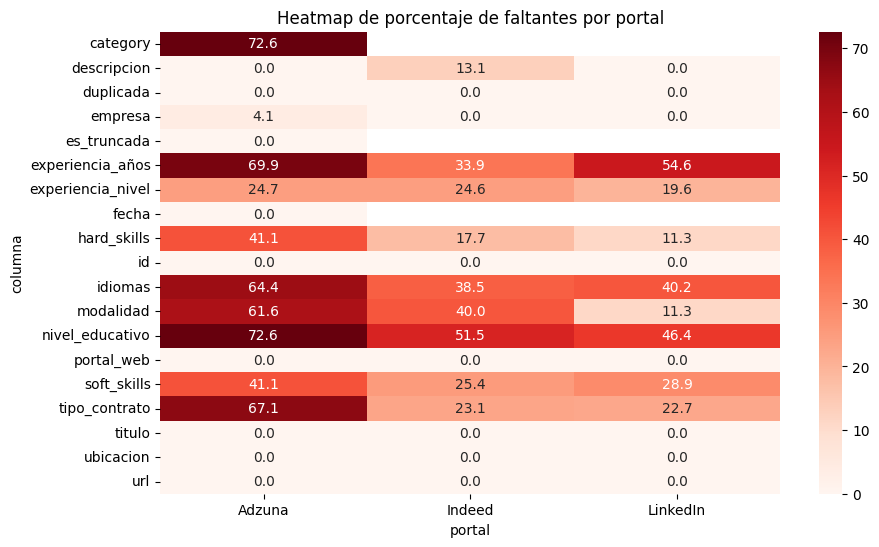

In [155]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df_faltantes_act,
    annot=True,
    cmap="Reds",
    fmt=".1f"
)
plt.title("Heatmap de porcentaje de faltantes por portal")
plt.show()

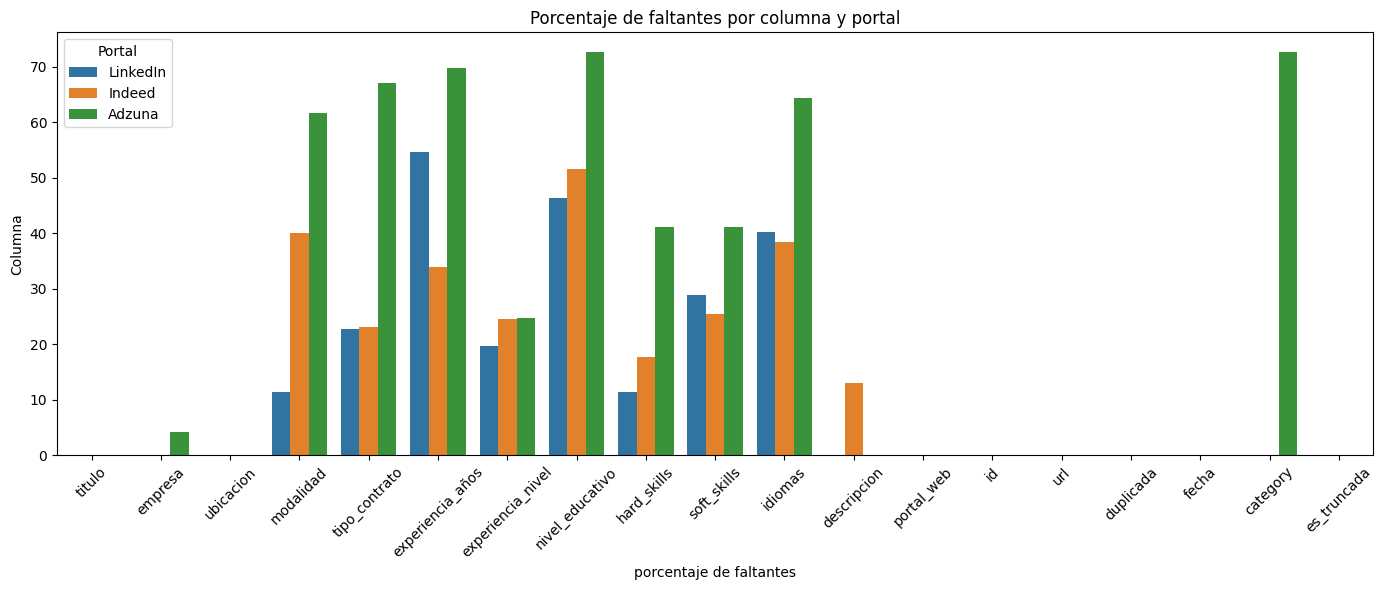

In [156]:
plt.figure(figsize=(14, 6))
sns.barplot(data=df_faltantes, y="porcentaje", x="columna", hue="portal")
plt.xticks(rotation=45)
plt.xlabel("porcentaje de faltantes")
plt.ylabel("Columna")
plt.title("Porcentaje de faltantes por columna y portal")
plt.legend(title="Portal")
plt.tight_layout()
plt.show()

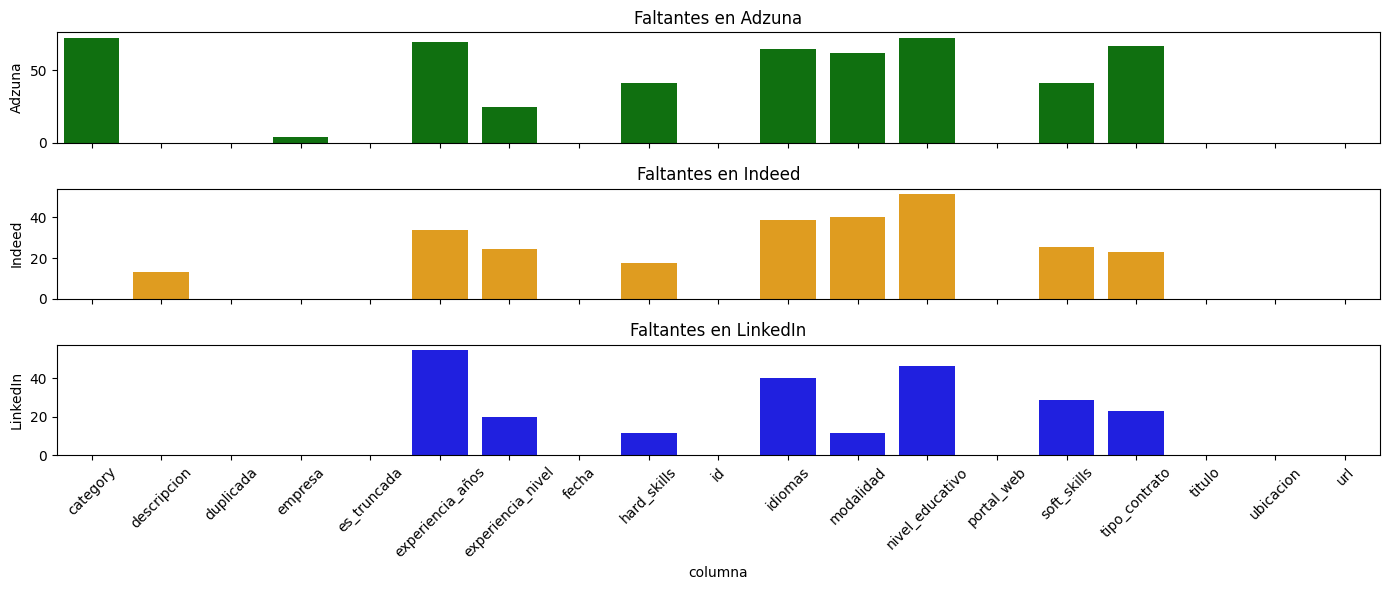

In [157]:
# Configuración de la figura
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
sns.barplot(data=df_faltantes_act, y="Adzuna", x=df_faltantes_act.index, ax=ax1, color="green")
sns.barplot(data=df_faltantes_act, y="Indeed", x=df_faltantes_act.index, ax=ax2, color="orange")
sns.barplot(data=df_faltantes_act, y="LinkedIn", x=df_faltantes_act.index, ax=ax3, color="blue")
ax3.tick_params(axis='x', rotation=45)
ax1.set_title("Faltantes en Adzuna")
ax2.set_title("Faltantes en Indeed")
ax3.set_title("Faltantes en LinkedIn")
plt.tight_layout()



In [158]:
# Métricas de calidad por portal (muy útil para informes)
def calidad_por_portal(df_faltantes, portal):
    dfp = df_faltantes[df_faltantes["portal"] == portal]

    completitud_promedio = 100 - dfp["porcentaje"].mean()
    columnas_vacias = dfp[dfp["porcentaje"] == 100]["columna"].tolist()
    columnas_completas = dfp[dfp["porcentaje"] == 0]["columna"].tolist()
    columnas_criticas = dfp[dfp["porcentaje"] > 50]["columna"].tolist()
    
    return {
        "portal": portal,
        "completitud_promedio": round(completitud_promedio, 2),
        "columnas_vacias": columnas_vacias,
        "columnas_completas": columnas_completas,
        "columnas_criticas": columnas_criticas
    }

In [159]:
# Obtener el análisis para cada portal
analisis_linkedin = calidad_por_portal(df_faltantes, "LinkedIn")
analisis_indeed = calidad_por_portal(df_faltantes, "Indeed")
analisis_adzuna = calidad_por_portal(df_faltantes, "Adzuna")


In [160]:
analisis_adzuna

{'portal': 'Adzuna',
 'completitud_promedio': np.float64(72.68),
 'columnas_vacias': [],
 'columnas_completas': ['titulo',
  'ubicacion',
  'fecha',
  'descripcion',
  'portal_web',
  'id',
  'url',
  'es_truncada',
  'duplicada'],
 'columnas_criticas': ['modalidad',
  'tipo_contrato',
  'experiencia_años',
  'nivel_educativo',
  'idiomas',
  'category']}

In [ ]:
# Exportar df para análisis posteriores
df_Adzuna.to_csv("df_Adzuna_clean.csv", index=False)
df_Indeed.to_csv("df_Indeed_clean.csv", index=False)
df_LinkedIn.to_csv("df_LinkedIn_clean.csv", index=False)
